# 1. Initialization and Setup

In [216]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import yaml

def load_config(filepath='config.yaml'):
    with open(filepath, 'r') as file:
        return yaml.safe_load(file)

config = load_config()
A = config['ellipsoid']['a']
B = config['ellipsoid']['b']
C = config['ellipsoid']['c']
TOLERANCE = config['sqp']['tolerance']
MAX_ITER = config['sqp']['max_iterations']

# 2. Mathematical Framework

In [217]:
def f(x, p):
    return np.sum((x - p)**2)

def g(x, a, b, c):
    return (x[0]**2 / a**2) + (x[1]**2 / b**2) + (x[2]**2 / c**2) - 1.0

def grad_f(x, p):
    return 2.0 * (x - p)

def grad_g(x, a, b, c):
    return np.array([
        2.0 * x[0] / a**2,
        2.0 * x[1] / b**2,
        2.0 * x[2] / c**2
    ])

# 3. KKT System and SQP Step

In [218]:
def build_kkt_system(x, p, lam, a, b, c):
    gf = grad_f(x, p)
    gg = grad_g(x, a, b, c)
    g_val = g(x, a, b, c)
    
    H = np.zeros((3, 3))
    H[0, 0] = 2.0 + (2.0 * lam / a**2)
    H[1, 1] = 2.0 + (2.0 * lam / b**2)
    H[2, 2] = 2.0 + (2.0 * lam / c**2)
    
    KKT_matrix = np.zeros((4, 4))
    KKT_matrix[:3, :3] = H
    KKT_matrix[:3, 3] = gg
    KKT_matrix[3, :3] = gg
    
    rhs = np.zeros(4)
    rhs[:3] = -gf - lam * gg
    rhs[3] = -g_val
    
    return KKT_matrix, rhs

def sqp_step(x, p, lam, a, b, c):
    KKT_matrix, rhs = build_kkt_system(x, p, lam, a, b, c)
    solution = np.linalg.solve(KKT_matrix, rhs)
    
    d = solution[:3]
    d_lam = solution[3]
    
    return d, d_lam

# 4. Metric Projection Pipeline

In [219]:
def project_point(p, x_init, lam_init, a, b, c, tol, max_iter):
    x = np.copy(x_init)
    lam = lam_init
    
    for iteration in range(max_iter):
        d, d_lam = sqp_step(x, p, lam, a, b, c)
        
        x = x + d
        lam = lam + d_lam
        
        if np.linalg.norm(d) <= tol:
            return x, lam, iteration + 1
            
    return x, lam, max_iter

# 5. Orbital Trajectory Generation

In [220]:
def generate_trajectory(a, b, c, altitude, timesteps):
    t = np.linspace(0, 2 * np.pi, timesteps)
    
    x_traj = (a + altitude) * np.cos(t)
    y_traj = (b + altitude) * np.sin(t) * np.cos(np.pi / 4) 
    z_traj = (c + altitude) * np.sin(t) * np.sin(np.pi / 4)
    
    return np.vstack((x_traj, y_traj, z_traj)).T

# 6. Execution and Warm-Starting Evaluation

In [221]:
trajectory = generate_trajectory(A, B, C, config['trajectory']['altitude'], config['trajectory']['timesteps'])

projections = []
iterations_history = []

x_current = np.array([A, 0.0, 0.0])
lam_current = 0.0

for p in trajectory:
    x_opt, lam_opt, iters = project_point(p, x_current, lam_current, A, B, C, TOLERANCE, MAX_ITER)
    
    projections.append(x_opt)
    iterations_history.append(iters)
    
    x_current = x_opt
    lam_current = lam_opt

projections = np.array(projections)

# 7. Static 3D Visualization

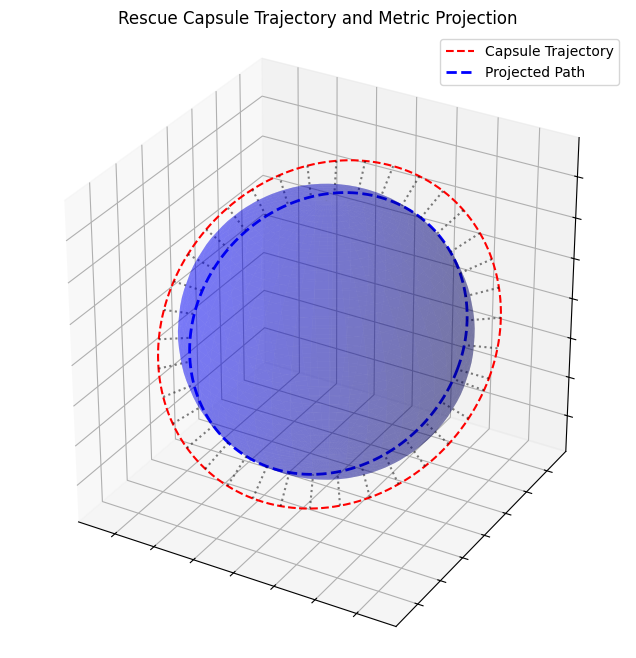

In [222]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_system(trajectory, projections, a, b, c):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='blue', alpha=0.3, edgecolor='none')
    ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], 'r--', label='Capsule Trajectory')
    ax.plot(projections[:, 0], projections[:, 1], projections[:, 2], 'b--', linewidth=2, label='Projected Path')
    
    for i in range(0, len(trajectory), 10):
        ax.plot([trajectory[i, 0], projections[i, 0]], 
                [trajectory[i, 1], projections[i, 1]], 
                [trajectory[i, 2], projections[i, 2]], 'k:', alpha=0.5)

    all_points = np.vstack((trajectory, projections))
    max_extent = np.max(np.abs([
        all_points.max(), 
        all_points.min(), 
        a, b, c
    ]))
    
    ax.set_xlim([-max_extent, max_extent])
    ax.set_ylim([-max_extent, max_extent])
    ax.set_zlim([-max_extent, max_extent])
    
    ax.set_box_aspect([1, 1, 1])

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_title('Rescue Capsule Trajectory and Metric Projection')
    ax.legend()
    plt.show()

plot_3d_system(trajectory, projections, A, B, C)

# 8. Animated 3D Visualization

In [223]:
def create_animation_gif(trajectory, projections, a, b, c, filename='animation.gif'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='blue', alpha=0.3, edgecolor='none')
    
    traj_line, = ax.plot([], [], [], 'r--', label='Capsule Trajectory')
    proj_line, = ax.plot([], [], [], 'b--', linewidth=2, label='Projected Path')
    
    rays = []
    for i in range(0, len(trajectory), 10):
        ray, = ax.plot([], [], [], 'k:', alpha=0.5)
        rays.append((i, ray))

    all_points = np.vstack((trajectory, projections))
    max_extent = np.max(np.abs([
        all_points.max(), 
        all_points.min(), 
        a, b, c
    ]))
    
    ax.set_xlim([-max_extent, max_extent])
    ax.set_ylim([-max_extent, max_extent])
    ax.set_zlim([-max_extent, max_extent])
    
    ax.set_box_aspect([1, 1, 1])

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_title('Rescue Capsule Trajectory and Metric Projection')
    ax.legend()

    def update(frame):
        traj_line.set_data(trajectory[:frame, 0], trajectory[:frame, 1])
        traj_line.set_3d_properties(trajectory[:frame, 2])
        
        proj_line.set_data(projections[:frame, 0], projections[:frame, 1])
        proj_line.set_3d_properties(projections[:frame, 2])
        
        for idx, ray in rays:
            if frame > idx:
                ray.set_data([trajectory[idx, 0], projections[idx, 0]], 
                             [trajectory[idx, 1], projections[idx, 1]])
                ray.set_3d_properties([trajectory[idx, 2], projections[idx, 2]])
                
        ax.view_init(elev=30, azim=frame * (360 / len(trajectory)))
        return [traj_line, proj_line] + [r[1] for r in rays]

    anim = FuncAnimation(fig, update, frames=len(trajectory), interval=50, blit=False)
    anim.save(filename, writer='pillow', fps=20)
    plt.close(fig)

create_animation_gif(trajectory, projections, A, B, C)